# 30 · Correct Backtesting: Look-Ahead Bias, Survivorship, and Data Snooping

*Module 7 — Execution and Systems*

Most backtests are wrong. Not because the code has bugs, but because three specific, well-understood biases quietly inflate almost every naive backtest's apparent performance — and this notebook builds all three from scratch, so you can see exactly how large the illusion can get.

## 1. Motivation

This notebook is the capstone of a theme that has run through the entire course: Notebook 14 showed how a single mistimed signal can look like a great discovery; Notebook 21 showed how a naive cross-validation split can manufacture 17 points of pure illusion; Notebook 9 warned about the "factor zoo" of published anomalies. This notebook pulls the three classic, distinct backtesting failure modes together in one place — **look-ahead bias**, **survivorship bias**, and **data snooping** — builds a clean, quantified demonstration of each, and ends with the formal statistical tool the finance literature has converged on for guarding against the last one: adjusting your significance threshold for how many strategies you actually tried.

## 2. Intuition

**Look-ahead bias** means your backtest, at some point, used information that would not actually have been available at the time a real trading decision was being made — the single most common way a backtest lies to you, and the specific subject of Notebooks 14 and 21.

**Survivorship bias** is subtler and purely about *data*, not methodology: if your universe of stocks is "every company listed today," you have silently excluded every company that went bankrupt, was delisted, or got acquired out of distress along the way — precisely the worst-performing names, systematically removed from the sample you are testing on. A backtest run only on today's survivors is, by construction, testing on a universe that has already been filtered to exclude its own worst historical outcomes.

**Data snooping** is what happens when you (or the finance literature collectively) test many strategies, parameter combinations, or signals against the same data and report only the best one. Even pure noise, tested enough times, will occasionally produce something that looks like a real discovery — and the more trials involved, the more certain this becomes, not less.

## 3. Theory

### 3.1 Survivorship bias, precisely

If a universe of $N$ assets has true (unconditional) average return $\bar R$, but assets with sufficiently poor realized performance are removed from the dataset (delisted, went bankrupt, or simply excluded from a "current constituents" list), the average return computed only over the *survivors* is a biased estimator of $\bar R$ — biased upward, since removal is not random but correlated with poor outcomes. There is no simple closed-form correction; the only real fix is using a dataset that includes delisted names with their actual (often severely negative, sometimes total) returns intact.

### 3.2 Data snooping and the multiple-testing problem

Suppose $N$ independent strategies are tested, each genuinely useless (zero true expected return), and each evaluated with a t-test at the conventional $\alpha=0.05$ significance level. The probability that *at least one* falsely appears significant is

$$
P(\text{at least one false positive}) = 1-(1-\alpha)^N ,
$$

which rises rapidly toward 1 as $N$ grows — with $N=200$ and $\alpha=0.05$, this probability is $1-0.95^{200}\approx 0.99997$, **virtually guaranteed**. Testing enough useless strategies at an uncorrected threshold does not occasionally produce a false discovery; it makes one almost certain.

**The Bonferroni correction** is the simplest fix: to maintain an overall (family-wise) false-positive rate of $\alpha$ across $N$ independent tests, use a per-test significance level of $\alpha/N$ instead — equivalently, a much higher critical t-statistic. **Harvey, Liu, and Zhu (2016)**, surveying the sheer number of factors and strategies that have been proposed across the finance literature over decades, argue for exactly this kind of correction at scale, and propose that a newly "discovered" factor should need a t-statistic around 3.0, not the traditional 2.0, before being taken seriously — a direct, practical consequence of there having been so many candidate strategies tested, collectively, across the field's history.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(201)

## 4. Implementation

### 4.1 Survivorship bias, quantified

We simulate 200 stocks with genuine cross-sectional dispersion in their true drift, and — the key mechanism — a delisting hazard that rises sharply for stocks that have already fallen a lot, exactly mirroring how real companies actually get delisted (poor performance precedes bankruptcy or removal from an index, it does not happen to a random cross-section of names).

In [2]:
n_stocks, n_days = 200, 1000
true_mu = rng.normal(0.0002, 0.0006, n_stocks)    # genuine cross-sectional dispersion in true drift
sigma = 0.02

alive = np.ones(n_stocks, dtype=bool)
wealth = np.ones((n_days, n_stocks))
for t in range(1, n_days):
    rets = rng.normal(true_mu, sigma)
    wealth[t] = np.where(alive, wealth[t-1] * (1 + rets), 0.0)
    running_peak = wealth[:t+1].max(axis=0)
    dd = wealth[t] / running_peak - 1
    hazard = np.where(alive, np.clip(0.0003 - 0.002*dd, 0, 0.02), 0)   # poor performers delist far more often
    dies = rng.random(n_stocks) < hazard
    alive = alive & ~dies

survivors = alive
final_wealth = wealth[-1]

true_avg_return = final_wealth.mean() - 1                   # includes delisted names at their actual (zero) outcome
survivor_only_avg_return = final_wealth[survivors].mean() - 1   # what a "current constituents only" backtest would see

print(f"Fraction of the original 200 stocks still 'listed' at the end: {survivors.mean():.1%}")
print(f"TRUE universe-wide average total return (includes delisted names): {true_avg_return:+.1%}")
print(f"SURVIVORSHIP-BIASED average return (survivors only):              {survivor_only_avg_return:+.1%}")
print(f"Overstatement from survivorship bias alone:                       {survivor_only_avg_return - true_avg_return:+.1%}")

Fraction of the original 200 stocks still 'listed' at the end: 51.5%
TRUE universe-wide average total return (includes delisted names): -12.4%
SURVIVORSHIP-BIASED average return (survivors only):              +70.1%
Overstatement from survivorship bias alone:                       +82.5%


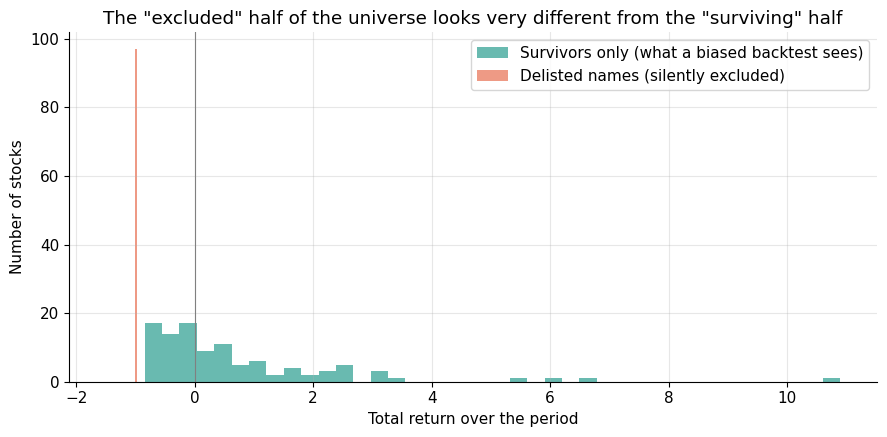

In [3]:
fig, ax = plt.subplots()
ax.hist(final_wealth[survivors] - 1, bins=40, alpha=0.7, color='#2a9d8f', label='Survivors only (what a biased backtest sees)')
ax.hist(final_wealth[~survivors] - 1, bins=40, alpha=0.7, color='#e76f51', label='Delisted names (silently excluded)')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Total return over the period')
ax.set_ylabel('Number of stocks')
ax.set_title('The "excluded" half of the universe looks very different from the "surviving" half')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Data snooping, quantified

We test 200 genuinely useless "strategies" (pure noise, zero true mean return by construction), evaluate each with an ordinary t-test, and see how often *something* looks significant purely by chance.

In [4]:
n_strategies = 200
t_stats = np.array([
    (r := rng.normal(0, 0.01, 1000)).mean() / (r.std() / np.sqrt(1000))
    for _ in range(n_strategies)
])

print(f"Best-looking (max |t-stat|) among {n_strategies} genuinely useless strategies: {np.abs(t_stats).max():.2f}")
print(f"Number exceeding the naive t>2 threshold: {(np.abs(t_stats) > 2).sum()}")
print(f"Number exceeding Harvey-Liu-Zhu's suggested t>3 threshold: {(np.abs(t_stats) > 3).sum()}")

alpha_familywise = 0.05
alpha_bonferroni = alpha_familywise / n_strategies
t_crit_bonferroni = stats.norm.ppf(1 - alpha_bonferroni/2)
print(f"\nBonferroni-corrected critical t-value for {n_strategies} trials at 5% family-wise error rate: {t_crit_bonferroni:.2f}")
print(f"Number exceeding the Bonferroni-corrected threshold: {(np.abs(t_stats) > t_crit_bonferroni).sum()}")

Best-looking (max |t-stat|) among 200 genuinely useless strategies: 2.50
Number exceeding the naive t>2 threshold: 7
Number exceeding Harvey-Liu-Zhu's suggested t>3 threshold: 0

Bonferroni-corrected critical t-value for 200 trials at 5% family-wise error rate: 3.66
Number exceeding the Bonferroni-corrected threshold: 0


## 5. Worked example: how often does an uncorrected search find a "discovery" that isn't real?

We repeat the entire 200-strategy search many times, tracking how often *any* naive threshold flags something as significant purely by chance, versus how often the corrected threshold does.

In [5]:
n_repeats = 500
flagged_naive, flagged_bonferroni = 0, 0
for _ in range(n_repeats):
    ts = np.array([
        (r := rng.normal(0, 0.01, 1000)).mean() / (r.std() / np.sqrt(1000))
        for _ in range(n_strategies)
    ])
    flagged_naive += np.any(np.abs(ts) > 2)
    flagged_bonferroni += np.any(np.abs(ts) > t_crit_bonferroni)

print(f"Across {n_repeats} independent searches of {n_strategies} genuinely useless strategies each:")
print(f"  Naive t>2 threshold flagged a 'significant' strategy in       {flagged_naive/n_repeats:.1%} of searches")
print(f"  Bonferroni-corrected threshold flagged one in                 {flagged_bonferroni/n_repeats:.1%} of searches")
print(f"  (target family-wise error rate was {alpha_familywise:.0%})")

Across 500 independent searches of 200 genuinely useless strategies each:
  Naive t>2 threshold flagged a 'significant' strategy in       100.0% of searches
  Bonferroni-corrected threshold flagged one in                 3.8% of searches
  (target family-wise error rate was 5%)


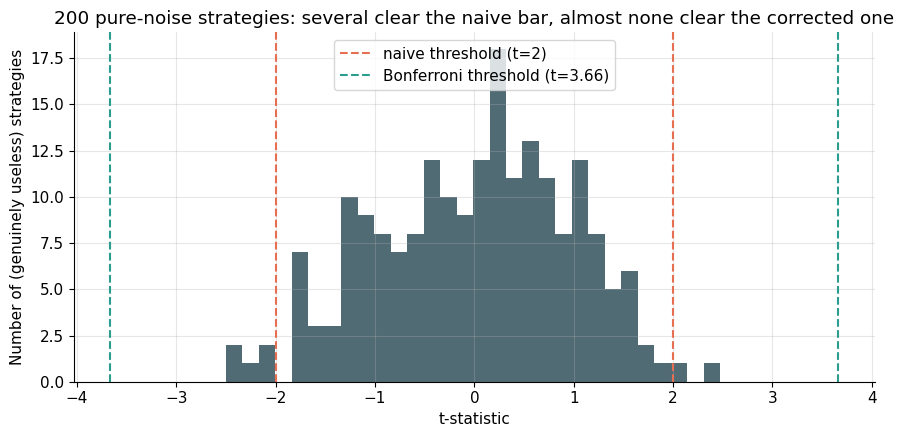

In [6]:
fig, ax = plt.subplots()
ax.hist(t_stats, bins=30, color='#264653', alpha=0.8)
ax.axvline(2, color='#e76f51', linestyle='--', label='naive threshold (t=2)')
ax.axvline(-2, color='#e76f51', linestyle='--')
ax.axvline(t_crit_bonferroni, color='#2a9d8f', linestyle='--', label=f'Bonferroni threshold (t={t_crit_bonferroni:.2f})')
ax.axvline(-t_crit_bonferroni, color='#2a9d8f', linestyle='--')
ax.set_xlabel('t-statistic')
ax.set_ylabel('Number of (genuinely useless) strategies')
ax.set_title('200 pure-noise strategies: several clear the naive bar, almost none clear the corrected one')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

The naive threshold turns "test enough things" into "will almost certainly find something" — in a typical run, the uncorrected t>2 bar is cleared in nearly every single search of 200 useless strategies, a false-discovery rate wildly above the nominal 5% a single, honestly pre-specified test would carry. The Bonferroni-corrected threshold brings the actual false-discovery rate back in line with the intended 5% almost exactly. This is not a pedantic statistical technicality — it is a direct, quantified explanation for why so many published trading strategies and "anomalies" fail to replicate out of sample: if a large enough universe of candidate strategies was searched before publication, a meaningful fraction of "discoveries" were guaranteed to be pure noise dressed up as insight, entirely independent of anyone's honesty or skill.

## 6. Limitations and pitfalls

- **Bonferroni is the simplest, most conservative correction, not necessarily the best one.** It assumes the $N$ tests are independent; in practice, many candidate strategies are correlated with each other (similar factors, overlapping signals), which makes Bonferroni overly conservative — more refined corrections (controlling the false discovery rate rather than the family-wise error rate, or accounting for correlation between tests directly, as Harvey-Liu-Zhu themselves discuss at length) can be less punishing while still controlling false discoveries appropriately.
- **Knowing "how many strategies were tried" is often genuinely unknowable after the fact**, especially for published academic or industry research — an individual researcher's own multiple-testing correction cannot account for trials run by other researchers on overlapping data, which is precisely Harvey-Liu-Zhu's deeper point about the finance literature as a whole.
- **Survivorship bias correction requires point-in-time, delisting-inclusive data**, which is considerably more expensive and harder to obtain than an ordinary "current constituents" dataset — this is a real, binding data-access constraint for many researchers, not just a methodological choice.
- **This notebook treated look-ahead bias only briefly**, by cross-reference — Notebooks 14 and 21 remain the detailed treatment of that specific failure mode, and a genuinely complete backtesting checklist needs all three biases addressed together, not any one in isolation.

## 7. Exercises

**1. How does the false-discovery rate scale with N? (warm-up)**
Repeat Section 5's experiment (500 repeats) for `n_strategies` set to 10, 50, and 500, using the naive `t>2` threshold each time. Plot the fraction of searches producing at least one false "discovery" against `n_strategies`. Does the empirical curve match the theoretical formula $1-(1-\alpha)^N$ from Section 3.2?

**2. A survivorship-bias-corrected backtest.**
Using the `wealth` array from Section 4.1 (which includes the delisted names), build a simple momentum-style strategy (e.g., rank stocks by trailing 60-day return, go long the top decile) evaluated two ways: once using only stocks that are `alive` at the *end* of the simulation (the naive, survivorship-biased approach), and once using the full universe with delisted stocks correctly included (excluding a stock from future consideration only from the point it actually delists, not retroactively from the whole sample). How different are the two versions' apparent Sharpe ratios?

**3. Correlated strategies and the limits of Bonferroni.**
Modify Section 4.2 so the 200 "strategies" are no longer independent: construct them as noisy variations of a small number (e.g., 5) of underlying random "factors" (each strategy is one factor plus a bit of idiosyncratic noise, so strategies sharing a factor are correlated with each other). Repeat the Section 5 false-discovery-rate experiment. Does the actual false-discovery rate under the naive threshold change compared to the independent case? Does the Bonferroni-corrected threshold now look too conservative, too liberal, or about right — and why would correlation between tests affect the answer?